# Evaluate Baseline Model (TF-IDF + Logistic Regression)

This notebook evaluates the performance of the baseline model on the test dataset. It includes metrics calculation and visualization of results.

In [ ]:
import os
import sys
from pathlib import Path

# Add src directory to python path:
src_path = str(Path(os.getcwd()).parent / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Configure plotting style:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

/Users/7312/Desktop/Repositories/phishing-transformer-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration:
EXPERIMENT_NAME = "phishing_baseline"
DATA_PATH = "../data/split/test.csv"
TEXT_COL = "Text"
LABEL_COL = "Is_Phishing"

## 1. Load Test Data

In [3]:
def load_test_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Test data not found at {path}")
    
    df = pd.read_csv(path)
    X = df[TEXT_COL].astype(str)
    y = df[LABEL_COL].map({False: 0, True: 1}).astype(int) if df[LABEL_COL].dtype == bool else df[LABEL_COL].astype(int)
    
    return X, y

X_test, y_test = load_test_data(DATA_PATH)
print(f"Loaded {len(X_test)} test samples")
print(f"Class distribution:\n{y_test.value_counts(normalize=True)}")

Loaded 1693 test samples
Class distribution:
Is_Phishing
1    0.555818
0    0.444182
Name: proportion, dtype: float64


## 2. Load Best Model from MLflow

In [4]:
# Set tracking URI to project root:
project_root = Path(os.getcwd()).parent
db_path = project_root / "mlflow.db"

if db_path.exists():
    tracking_uri = f"sqlite:///{db_path}"
    print(f"Setting tracking URI to: {tracking_uri}")
    mlflow.set_tracking_uri(tracking_uri)
    
else:
    print("Warning: mlflow.db not found, using default mlruns")

mlflow.set_experiment(EXPERIMENT_NAME)
runs = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME], order_by=["metrics.val_f1 DESC"])

if runs.empty:
    raise ValueError(f"No runs found for experiment '{EXPERIMENT_NAME}'")

best_run = runs.iloc[0]
run_id = best_run.run_id
model_uri = f"runs:/{run_id}/model"

print(f"Loading best model from run_id: {run_id}")
print(f"Validation F1: {best_run['metrics.val_f1']:.4f}")

model = mlflow.sklearn.load_model(model_uri)

Setting tracking URI to: sqlite:////Users/7312/Desktop/Repositories/phishing-transformer-detection/mlflow.db


2026/02/23 15:09:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/23 15:09:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/23 15:09:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/23 15:09:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/23 15:09:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/23 15:09:49 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/23 15:09:49 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/23 15:09:49 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Loading best model from run_id: 6a4eccda48044e62a0953429cc910110
Validation F1: 0.9605


## 3. Make Predictions

In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## 4. Evaluation Metrics

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.94      0.96      0.95       752
    Phishing       0.97      0.95      0.96       941

    accuracy                           0.95      1693
   macro avg       0.95      0.96      0.95      1693
weighted avg       0.95      0.95      0.95      1693



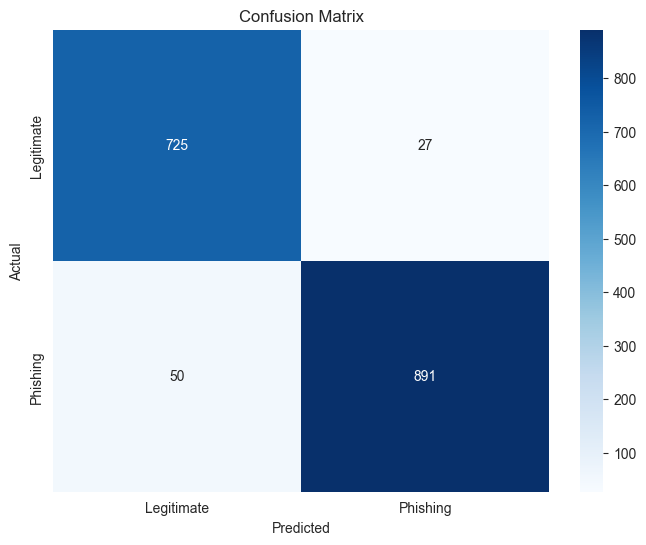

In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 5. ROC Curve

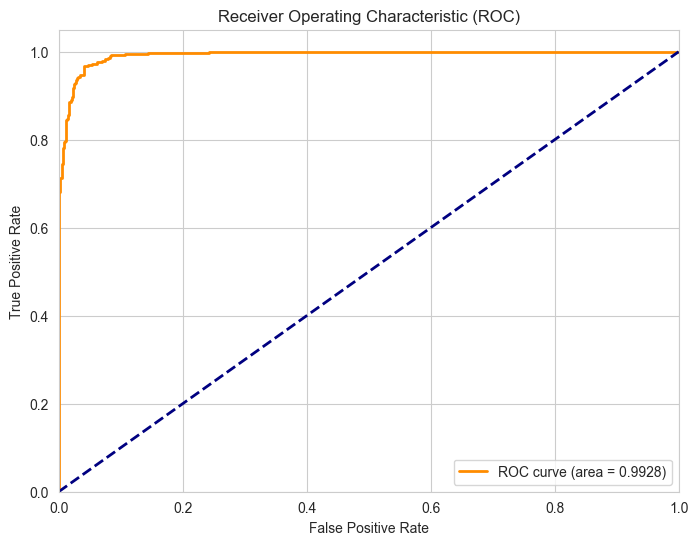

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## 6. Precision-Recall Curve

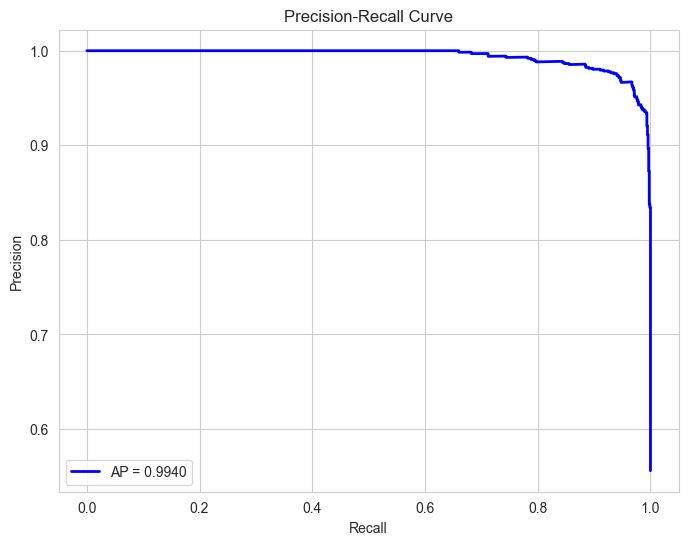

In [8]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {average_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()